In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Chuyênđề3/sleeptime_prediction_dataset.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     2000 non-null   float64
 1   ReadingTime     2000 non-null   float64
 2   PhoneTime       2000 non-null   float64
 3   WorkHours       2000 non-null   float64
 4   CaffeineIntake  2000 non-null   float64
 5   RelaxationTime  2000 non-null   float64
 6   SleepTime       2000 non-null   float64
dtypes: float64(7)
memory usage: 109.5 KB


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# --- BƯỚC 2: XỬ LÝ NGOẠI LAI (OUTLIERS) ---
# Sử dụng phương pháp IQR để lọc bỏ các giá trị SleepTime bất thường
Q1 = df['SleepTime'].quantile(0.25)
Q3 = df['SleepTime'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc dữ liệu
df_clean = df[(df['SleepTime'] >= lower_bound) & (df['SleepTime'] <= upper_bound)]
print(f"\nKích thước trước khi lọc: {df.shape}")
print(f"Kích thước sau khi lọc outliers: {df_clean.shape}")


Kích thước trước khi lọc: (2000, 7)
Kích thước sau khi lọc outliers: (1936, 7)


In [ ]:
# --- BƯỚC 3: CHIA DỮ LIỆU (SPLIT) ---
X = df_clean.drop('SleepTime', axis=1) # Các đặc trưng (Features)
y = df_clean['SleepTime']              # Biến mục tiêu (Target)

# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- BƯỚC 4: CHUẨN HÓA (SCALING) ---
scaler = StandardScaler()

# Học từ tập train và áp dụng lên cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chuyển về dạng DataFrame để dễ quan sát (tùy chọn)
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nDữ liệu sau khi chuẩn hóa (5 dòng đầu của tập train):")
X_train_final.head()


Dữ liệu sau khi chuẩn hóa (5 dòng đầu của tập train):


,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime
0,-0.883477,-0.306671,0.649196,-0.449845,0.726040,-0.759556
1,1.699229,-1.422076,-1.381173,-0.219628,-1.029126,0.817493
2,-0.509664,0.878447,-0.905980,1.553042,0.051068,-1.170960
3,1.019570,0.163890,-0.551746,-0.202362,1.613520,-0.999542
4,-1.483843,-0.480953,1.081189,-0.996610,1.651210,1.451741


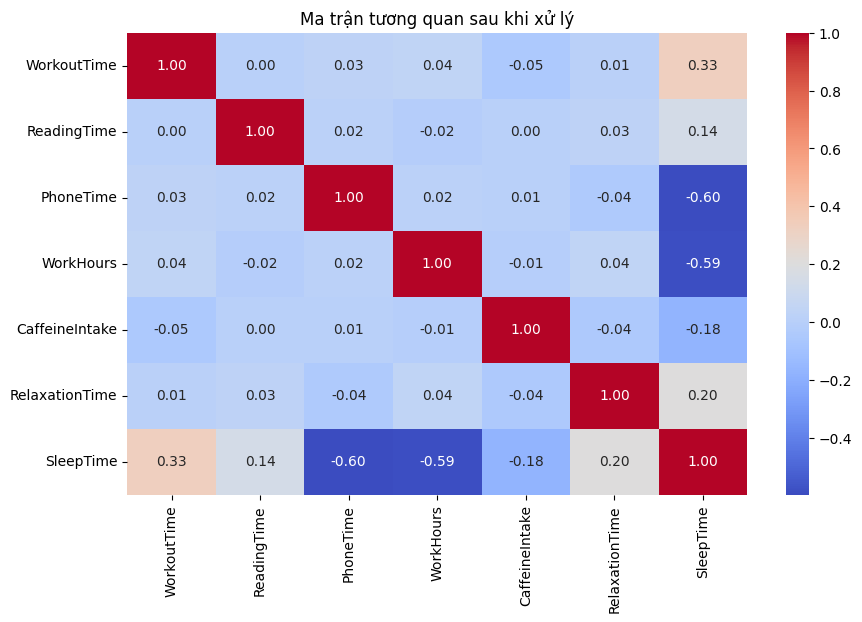

In [ ]:
# --- BƯỚC 5: KIỂM TRA TƯƠNG QUAN (VẼ HÌNH) ---
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan sau khi xử lý')
plt.show()

In [ ]:
X_train = X_train_scaled
X_test = X_test_scaled

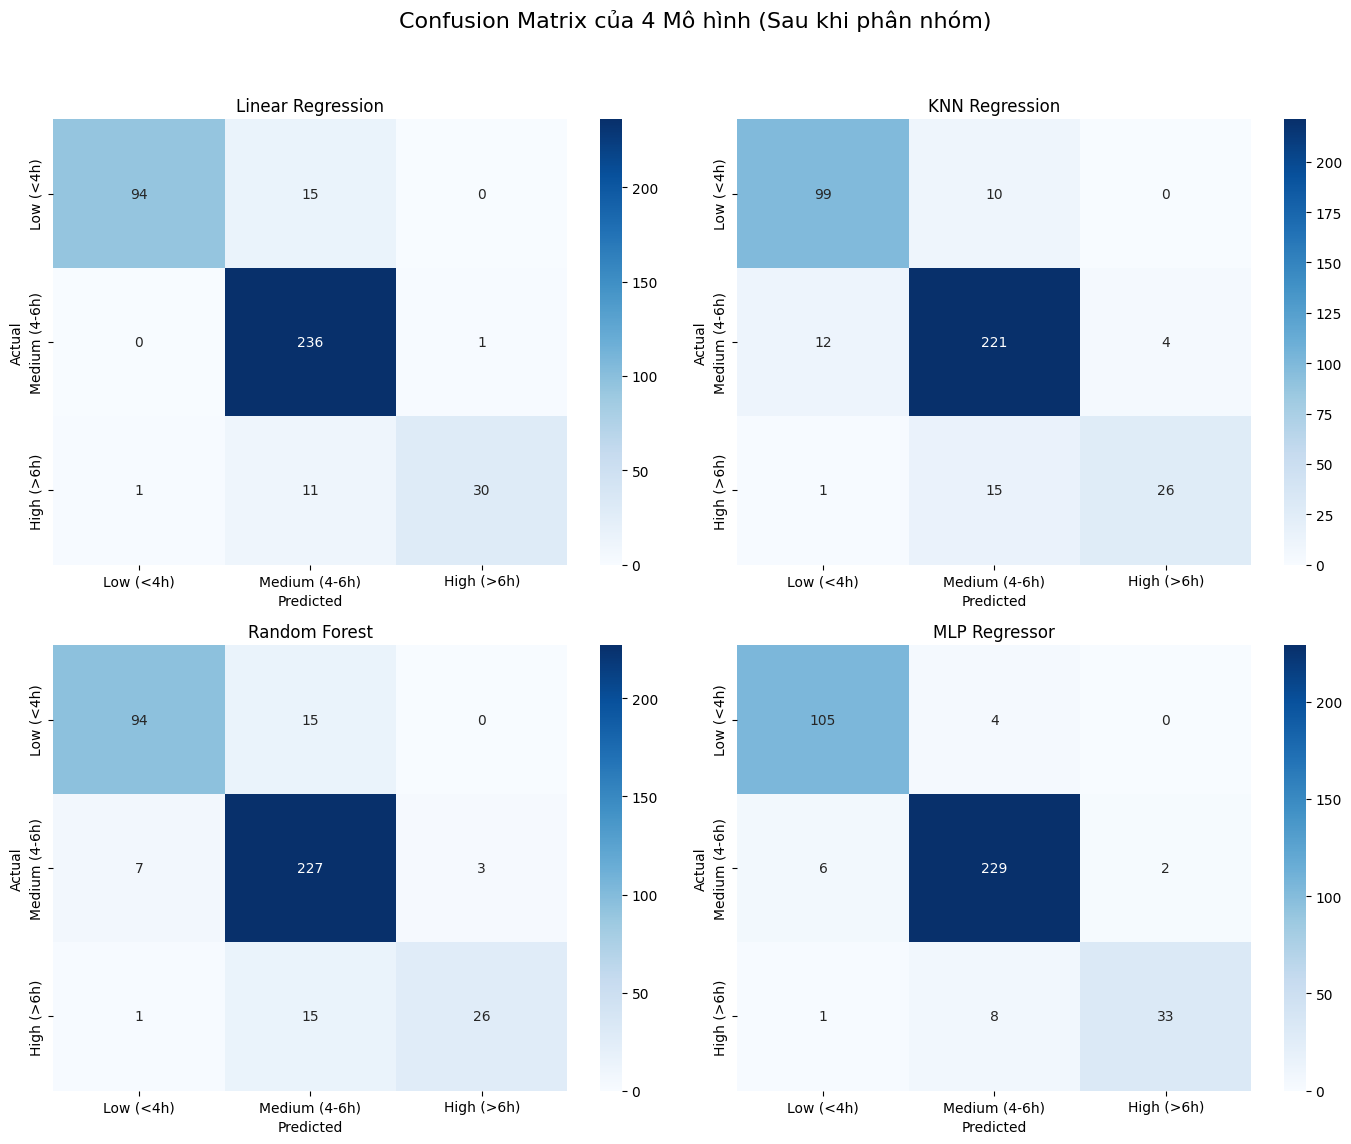

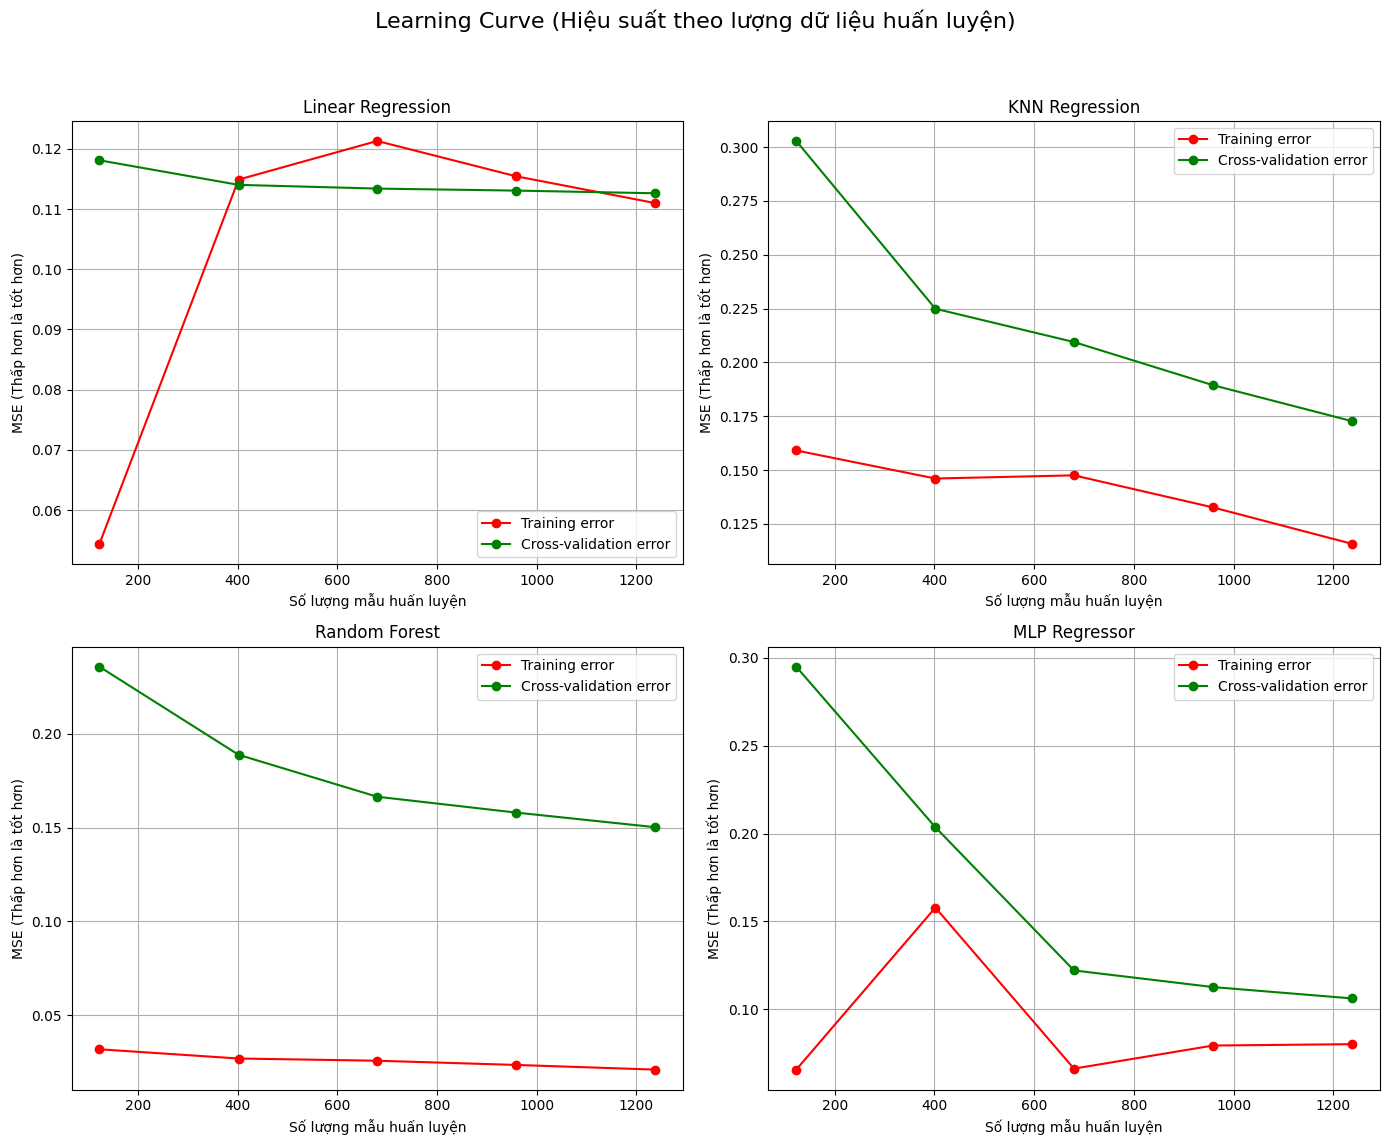

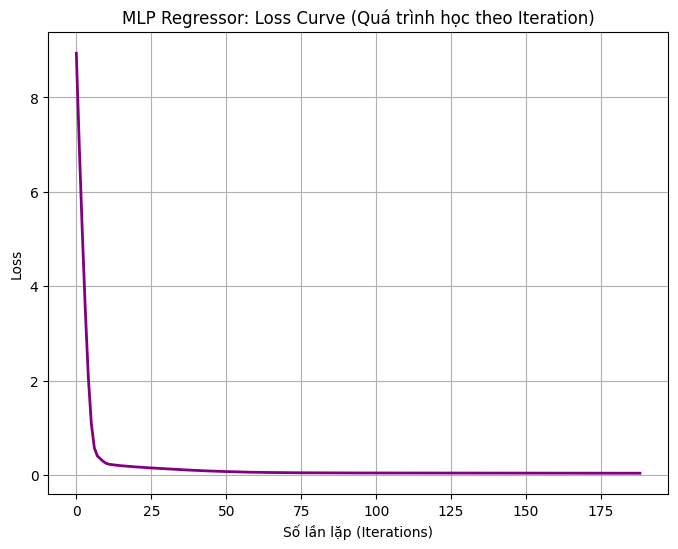

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

models = {
    "Linear Regression": LinearRegression(),
    "KNN Regression": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}
# --- BƯỚC 3: VẼ CONFUSION MATRIX CHO TỪNG MÔ HÌNH ---

# Hàm chuyển đổi số giờ thành phân loại
def categorize_sleep(hours):
    if hours < 4: return 'Low (<4h)'
    elif hours <= 6: return 'Medium (4-6h)'
    else: return 'High (>6h)'

labels = ['Low (<4h)', 'Medium (4-6h)', 'High (>6h)']
y_test_cat = y_test.apply(categorize_sleep)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrix của 4 Mô hình (Sau khi phân nhóm)', fontsize=16)

for ax, (name, model) in zip(axes.flatten(), models.items()):
    # Huấn luyện
    model.fit(X_train_scaled, y_train)

    # Dự đoán và chuyển đổi sang nhãn
    y_pred = model.predict(X_test_scaled)
    y_pred_cat = pd.Series(y_pred).apply(categorize_sleep)

    # Tạo ma trận
    cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)

    # Vẽ
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- BƯỚC 4: VẼ LEARNING CURVE (HIỆU SUẤT THEO KÍCH THƯỚC DỮ LIỆU) ---
# Biểu đồ này cho thấy mô hình có bị Overfitting hay Underfitting không khi tăng dữ liệu

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Learning Curve (Hiệu suất theo lượng dữ liệu huấn luyện)', fontsize=16)

for ax, (name, model) in zip(axes.flatten(), models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )

    # Chuyển đổi score từ âm sang dương (MSE)
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training error")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation error")

    ax.set_title(name)
    ax.set_xlabel("Số lượng mẫu huấn luyện")
    ax.set_ylabel("MSE (Thấp hơn là tốt hơn)")
    ax.legend(loc="best")
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- BƯỚC 5: BIỂU ĐỒ RIÊNG CHO NEURAL NETWORK (LOSS CURVE) ---
# Chỉ có MLP mới có khái niệm Loss theo Iteration
plt.figure(figsize=(8, 6))
plt.plot(models['MLP Regressor'].loss_curve_, color='purple', lw=2)
plt.title('MLP Regressor: Loss Curve (Quá trình học theo Iteration)')
plt.xlabel('Số lần lặp (Iterations)')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
# --- BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ ---
results = []

print(f"{'Model':<20} | {'RMSE':<10} | {'R2 Score':<10} | {'MAE': <10}")
print("-" * 60)

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "RMSE": rmse, "R2 Score": r2, "MAE": mae })
    print(f"{name:<20} | {rmse:.4f}     | {r2:.4f}     | {mae:.4f}")

Model                | RMSE       | R2 Score   | MAE       
------------------------------------------------------------
Linear Regression    | 0.2898     | 0.9218     | 0.1147
KNN Regression       | 0.3755     | 0.8688     | 0.2230
Random Forest        | 0.3464     | 0.8883     | 0.2033
MLP Regressor        | 0.2873     | 0.9232     | 0.1127


/tmp/ipython-input-2511033129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")


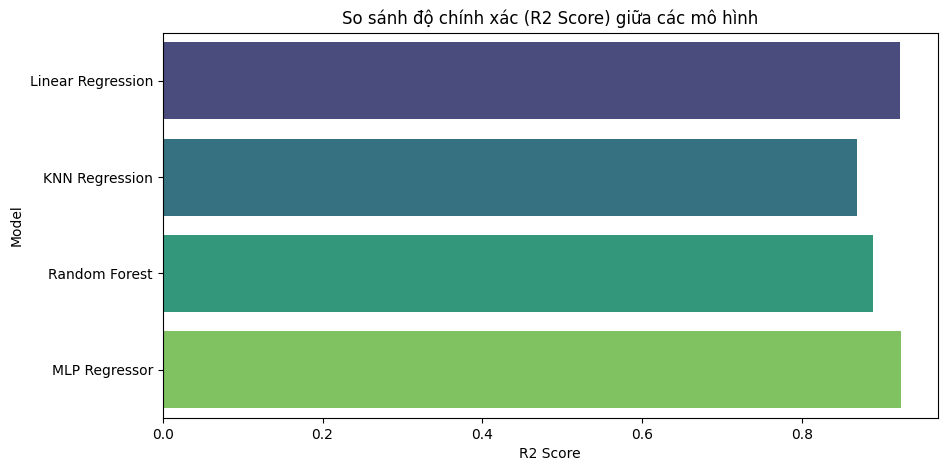

In [ ]:
# --- BƯỚC 4: VẼ BIỂU ĐỒ SO SÁNH ---
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")
plt.title("So sánh độ chính xác (R2 Score) giữa các mô hình")
plt.show()

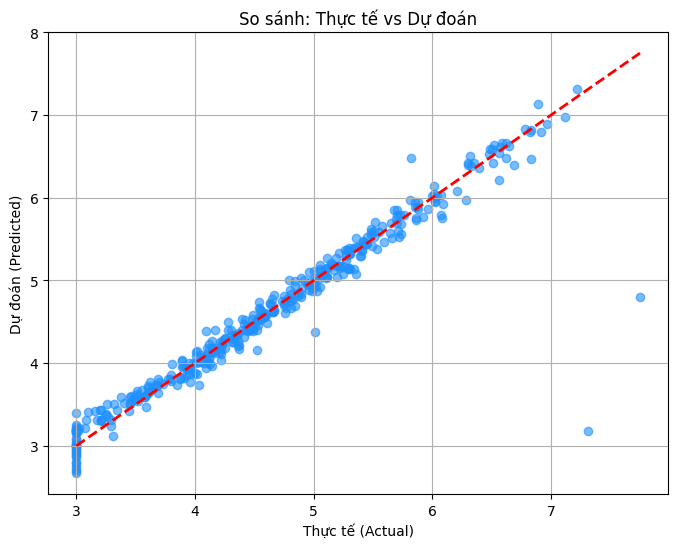

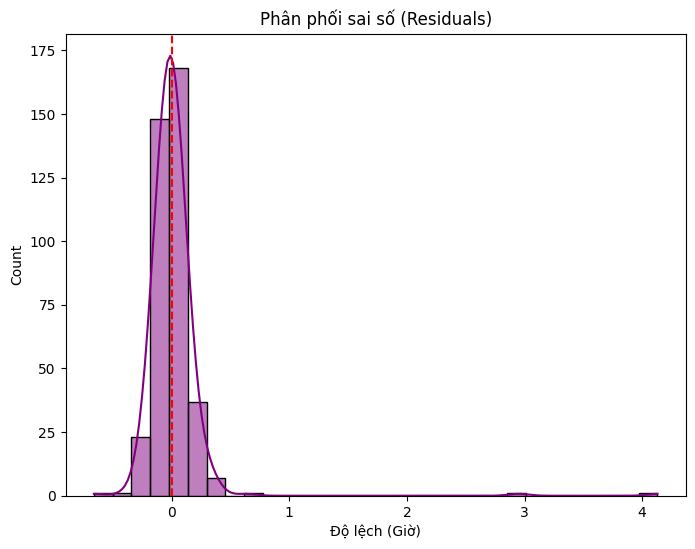

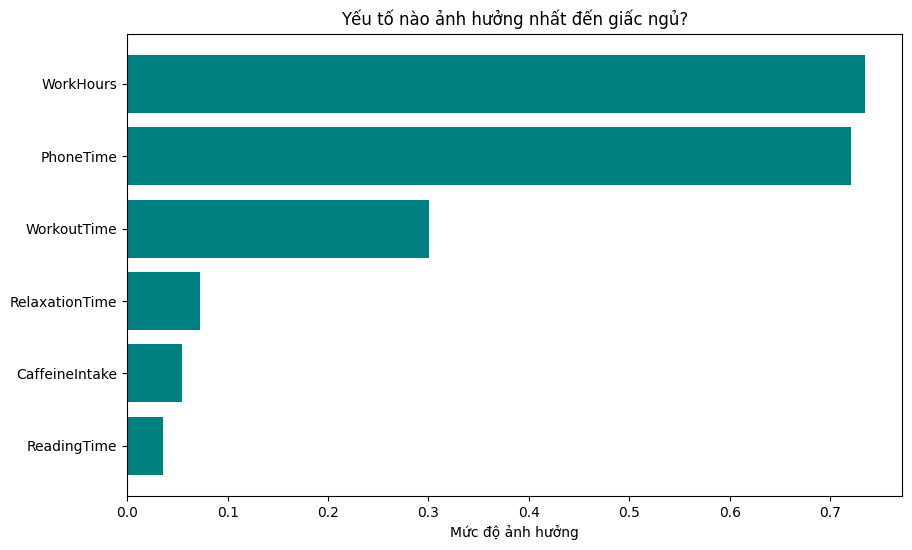

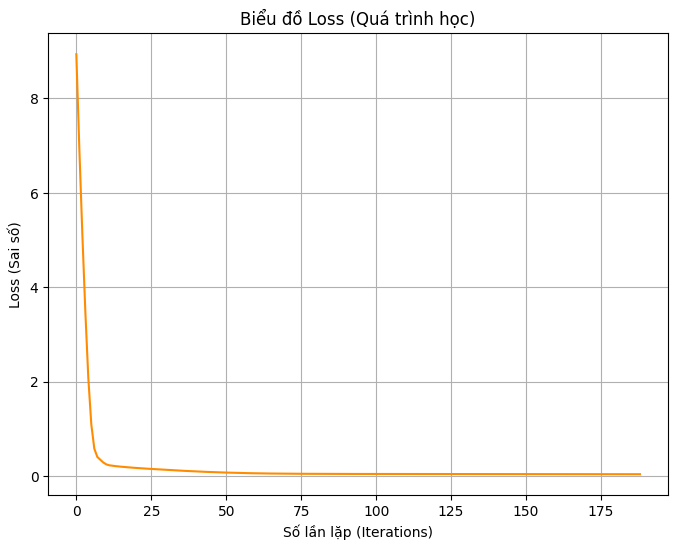

In [ ]:
from sklearn.inspection import permutation_importance

# --- 1. Thực tế vs Dự đoán ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Đường chuẩn
plt.xlabel('Thực tế (Actual)')
plt.ylabel('Dự đoán (Predicted)')
plt.title('So sánh: Thực tế vs Dự đoán')
plt.grid(True)
plt.show()

# --- 2. Phân phối Sai số ---
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Phân phối sai số (Residuals)')
plt.xlabel('Độ lệch (Giờ)')
plt.axvline(x=0, color='red', linestyle='--') # Mốc 0
plt.show()

# --- 3. Tầm quan trọng của các yếu tố (Feature Importance) ---
# Tính toán mức độ quan trọng
result = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
# X.columns là tên các cột dữ liệu đầu vào
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx], color='teal')
plt.xlabel("Mức độ ảnh hưởng")
plt.title("Yếu tố nào ảnh hưởng nhất đến giấc ngủ?")
plt.show()

# --- 4. Quá trình học (Loss Curve) ---
plt.figure(figsize=(8, 6))
plt.plot(model.loss_curve_, color='darkorange')
plt.title('Biểu đồ Loss (Quá trình học)')
plt.xlabel('Số lần lặp (Iterations)')
plt.ylabel('Loss (Sai số)')
plt.grid(True)
plt.show()

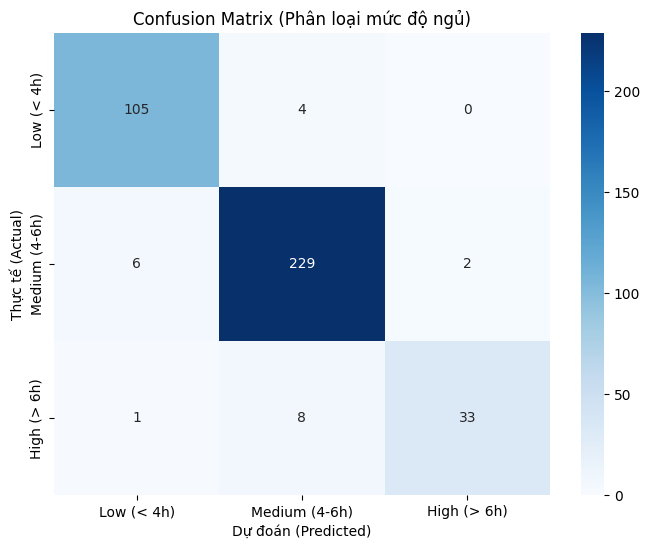

Báo cáo phân loại (Classification Report):
               precision    recall  f1-score   support

   Low (< 4h)       0.94      0.96      0.95       109
Medium (4-6h)       0.95      0.97      0.96       237
  High (> 6h)       0.94      0.79      0.86        42

     accuracy                           0.95       388
    macro avg       0.94      0.91      0.92       388
 weighted avg       0.95      0.95      0.94       388



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# --- BƯỚC 1: HÀM PHÂN LOẠI ---
def categorize_sleep(hours):
    if hours < 4:
        return 'Low (< 4h)'
    elif hours <= 6:
        return 'Medium (4-6h)'
    else:
        return 'High (> 6h)'

# --- BƯỚC 2: CHUYỂN ĐỔI DỮ LIỆU ---
# Áp dụng hàm phân loại cho kết quả thực tế và dự đoán
y_test_cat = pd.Series(y_test).apply(categorize_sleep)
y_pred_cat = pd.Series(y_pred).apply(categorize_sleep)

# Định nghĩa thứ tự nhãn để biểu đồ dễ nhìn
labels = ['Low (< 4h)', 'Medium (4-6h)', 'High (> 6h)']

# --- BƯỚC 3: VẼ CONFUSION MATRIX ---
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Phân loại mức độ ngủ)')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# --- BƯỚC 4: IN BÁO CÁO CHI TIẾT ---
print("Báo cáo phân loại (Classification Report):")
print(classification_report(y_test_cat, y_pred_cat, labels=labels))

In [ ]:
new_data = [
    # Người 1: Lối sống cân bằng
    {'WorkoutTime': 1.5, 'ReadingTime': 1.0, 'PhoneTime': 1.5, 'WorkHours': 6.0, 'CaffeineIntake': 50, 'RelaxationTime': 1.5},
    # Người 2: Stress, làm việc nhiều, uống nhiều cafe
    {'WorkoutTime': 0.5, 'ReadingTime': 0.2, 'PhoneTime': 5.0, 'WorkHours': 9.0, 'CaffeineIntake': 250, 'RelaxationTime': 0.2},
    # Người 3: Rất thư giãn
    {'WorkoutTime': 2.0, 'ReadingTime': 2.0, 'PhoneTime': 1.0, 'WorkHours': 5.0, 'CaffeineIntake': 10, 'RelaxationTime': 2.0}
]

# --- DỰ ĐOÁN VÀ SO SÁNH ---
new_df = pd.DataFrame(new_data)
new_df_scaled = scaler.transform(new_df) # Đừng quên scale dữ liệu mới!

results = {}
# Thêm cột mô tả người dùng
results['Người dùng'] = [f"Người {i+1}" for i in range(len(new_data))]

# Chạy dự đoán cho từng model
for name, model in models.items():
    predictions = model.predict(new_df_scaled)
    results[name] = [f"{pred:.2f} giờ" for pred in predictions]

# Hiển thị bảng kết quả
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("BẢNG SO SÁNH DỰ ĐOÁN GIẤC NGỦ (4 MÔ HÌNH)")
print("="*80)
print(results_df.to_string(index=False))


BẢNG SO SÁNH DỰ ĐOÁN GIẤC NGỦ (4 MÔ HÌNH)
Người dùng Linear Regression KNN Regression Random Forest MLP Regressor
   Người 1          6.16 giờ       6.37 giờ      6.18 giờ      6.14 giờ
   Người 2          1.64 giờ       3.00 giờ      3.00 giờ      2.82 giờ
   Người 3          7.53 giờ       7.09 giờ      7.01 giờ      7.85 giờ
